# Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

# - Carga de datos

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/demographic_health_data.csv')
df

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [37]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB
None


In [38]:
print(df.columns.tolist())

['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with les

El dataser tiene más de cien columnas y 3140 filas, lo cual representa un desafío por la contidad de información, sin embargo, se nota por los nombres que ya están fragmentado de manera entendible por edades, raza y otros factores.

Podemos agrupar tus variables en 4 categorías lógicas:

Identificadores: fips, COUNTY_NAME, STATE_NAME, Urban_rural_code.

Demografía (Edad y Raza): TOT_POP, 0-9, % White-alone, Population Aged 60+, etc.

Socioeconomía: PCTPOVALL_2018 (Pobreza), MEDHHINC_2018 (Ingresos), Unemployment_rate_2018, y niveles de Educación.

Recursos de Salud: Active Physicians per 100000, Total Hospitals, ICU Beds_x.

Resultados de Salud (Target): anycondition_prevalence, Obesity_prevalence, diabetes_prevalence.


In [39]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].isin(['Unknown', 'N/A', 'None', ' ', 'unknown']).sum()} nulos de texto")

COUNTY_NAME: 0 nulos de texto
STATE_NAME: 0 nulos de texto


/tmp/ipykernel_1271/2955561338.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


No se encontraron valores nulos

In [51]:
cols_clave = ['anycondition_prevalence', 'R_death_2018','Heart disease_prevalence', 'diabetes_prevalence','PCTPOVALL_2018', 'MEDHHINC_2018', 
              'Active Physicians per 100000 Population 2018 (AAMC)', 'Unemployment_rate_2018'
              ]

df[cols_clave].describe().T

,count,mean,std,min,25%,50%,75%,max
anycondition_prevalence,3140.0,46.793917,6.379448,22.0,42.9,47.2,51.00,66.2
R_death_2018,3140.0,10.365287,2.687543,0.0,8.7,10.4,12.20,21.9
Heart disease_prevalence,3140.0,8.607803,1.758587,3.5,7.4,8.6,9.80,15.1
diabetes_prevalence,3140.0,13.073503,2.724351,6.1,11.2,12.8,14.80,25.6
PCTPOVALL_2018,3140.0,15.159459,6.131874,0.0,10.8,14.1,18.30,54.0
MEDHHINC_2018,3140.0,52767.083758,13907.992668,0.0,43677.0,50564.5,58822.25,140382.0
Active Physicians per 100000 Population 2018 (AAMC),3140.0,254.923567,42.291759,191.3,227.6,247.1,278.80,847.0
Unemployment_rate_2018,3140.0,4.131338,1.503013,0.0,3.1,3.9,4.80,19.9


Las variables más interesantes de tener como objetivo para analizar serían:

anycondition_prevalence	: Indica el % de la población con al menos una enfermedad crónica.

R_death_2018: Tasa de mortalidad por cada 1,000 habitantes.

Heart disease_prevalence o diabetes_prevalence: Si preferimos enfocarnos en una enfermedad específica.

### Para este análisis se tomará como objetivo se anycondition_prevalence


## Limpieza de Intervalos de Confianza (CI) y variables de identificación
Las columnas Lower 95% CI y Upper 95% CI son redundantes para un modelo de regresión, ya que son derivadas matemáticas de la prevalencia principal. Mantenerlas causaría multicolinealidad extrema.

Para el modelo, nombres de condados o estados no sirven (son texto único). Solo nos quedaremos con las numéricas

In [44]:
cols_a_eliminar = [col for col in df.columns if '95% CI' in col or 'Lower' in col or 'Upper' in col]

# También eliminamos las que terminan en "_number" (son el conteo absoluto, ya tenemos el %)
cols_conteo = [col for col in df.columns if '_number' in col]

# Aplicamos la limpieza
df = df.drop(columns=cols_a_eliminar + cols_conteo)

print(f"Columnas eliminadas: {len(cols_a_eliminar) + len(cols_conteo)}")
print(f"Columnas restantes: {len(df.columns)}")

Columnas eliminadas: 18
Columnas restantes: 90


In [48]:
cols_id = ['fips', 'COUNTY_NAME', 'STATE_NAME', 'STATE_FIPS', 'CNTY_FIPS']
df = df.drop(columns=cols_id)
print(f"Columnas restantes: {len(df.columns)}")

Columnas restantes: 85


# - Análisis de variables

In [49]:
target = 'anycondition_prevalence'

# Calculamos correlaciones y vemos las 10 más fuertes (positivas o negativas)
correlaciones = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)
print("Top 20 variables que más influyen en la salud del condado:")
print(correlaciones.head(20))

Top 20 variables que más influyen en la salud del condado:
anycondition_prevalence                                           1.000000
Obesity_prevalence                                                0.894438
diabetes_prevalence                                               0.850219
COPD_prevalence                                                   0.810700
Heart disease_prevalence                                          0.784088
Percent of adults with a bachelor's degree or higher 2014-18      0.768119
CKD_prevalence                                                    0.734549
CI90LBINC_2018                                                    0.708710
Median_Household_Income_2018                                      0.706113
MEDHHINC_2018                                                     0.706113
CI90UBINC_2018                                                    0.698453
PCTPOV017_2018                                                    0.694607
PCTPOV517_2018                           

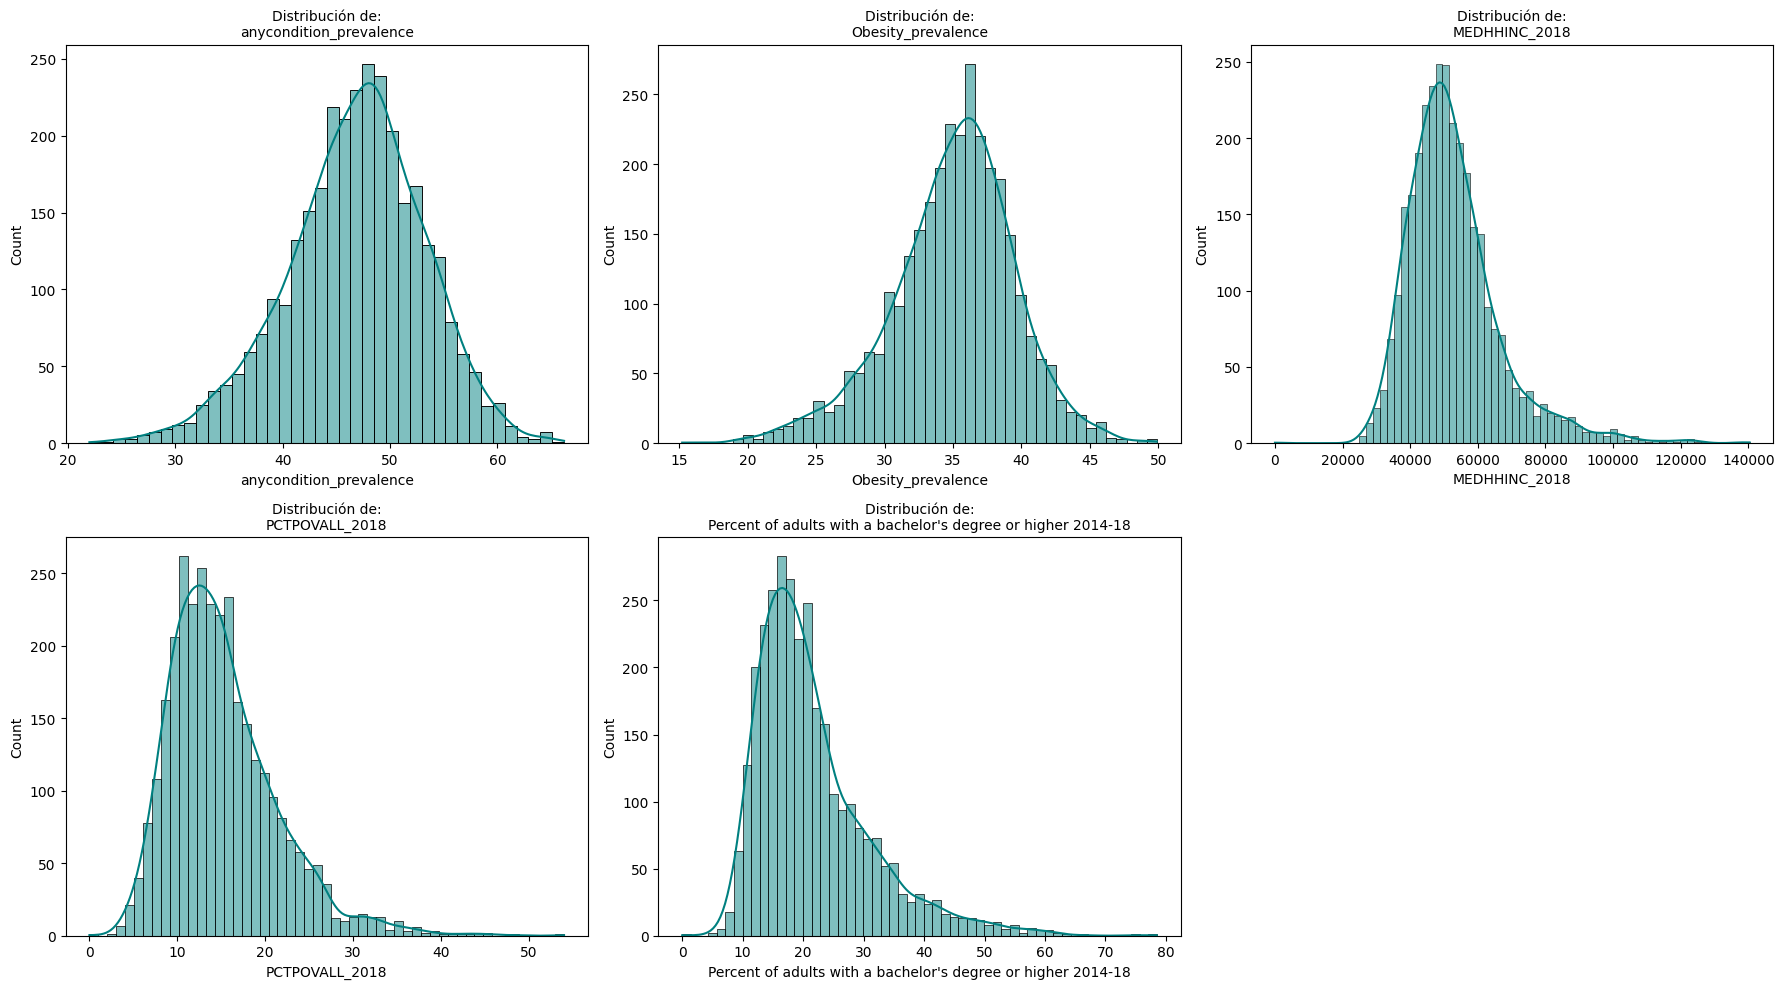

In [ ]:
# Selección de variables representativas del Top 20
cols_dist = ['anycondition_prevalence', 'Obesity_prevalence', 
             'MEDHHINC_2018', 'PCTPOVALL_2018', 
             "Percent of adults with a bachelor's degree or higher 2014-18"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_dist):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de:\n{col}', fontsize=10)

# Eliminamos el último eje vacío si no lo usamos
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

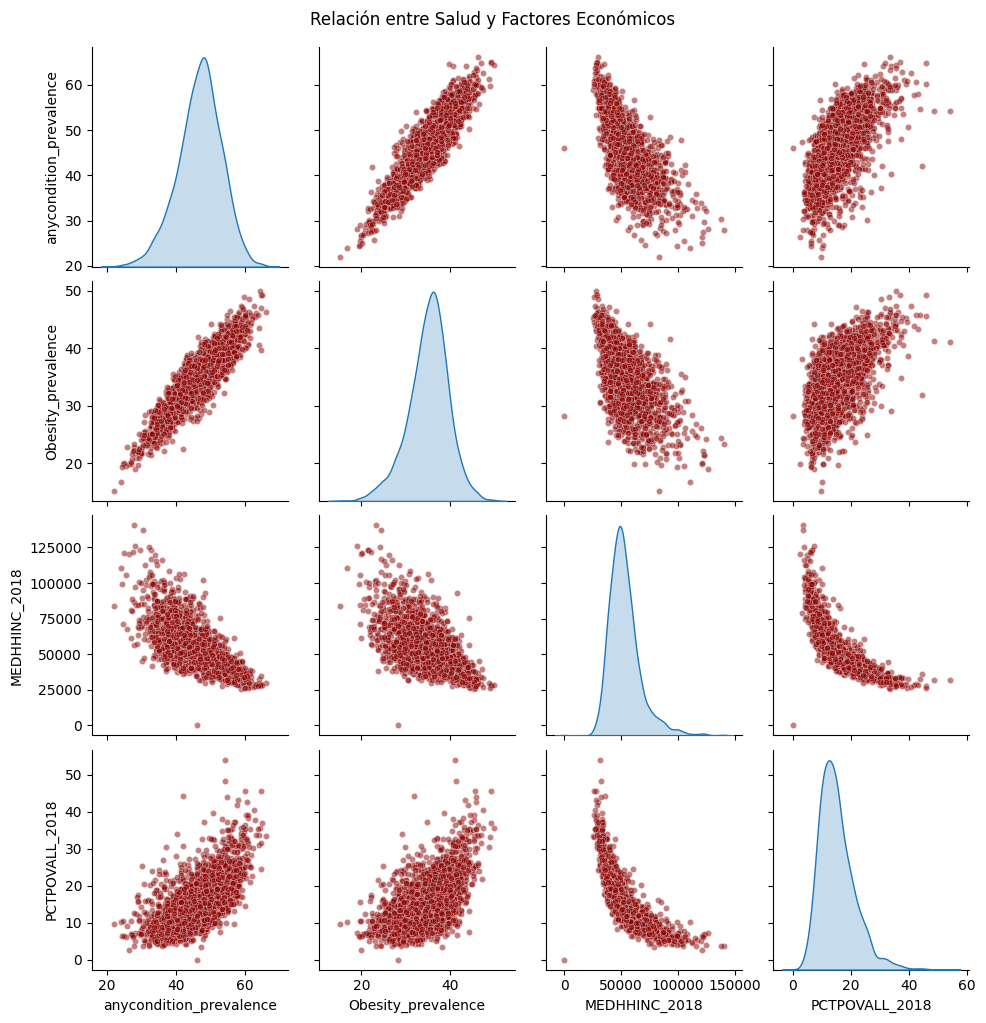

In [53]:
# Variables clave para el cruce
cols_pair = ['anycondition_prevalence', 'Obesity_prevalence', 'MEDHHINC_2018', 'PCTPOVALL_2018']

sns.pairplot(df[cols_pair], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20, 'color': 'darkred'})
plt.suptitle('Relación entre Salud y Factores Económicos', y=1.02)
plt.show()

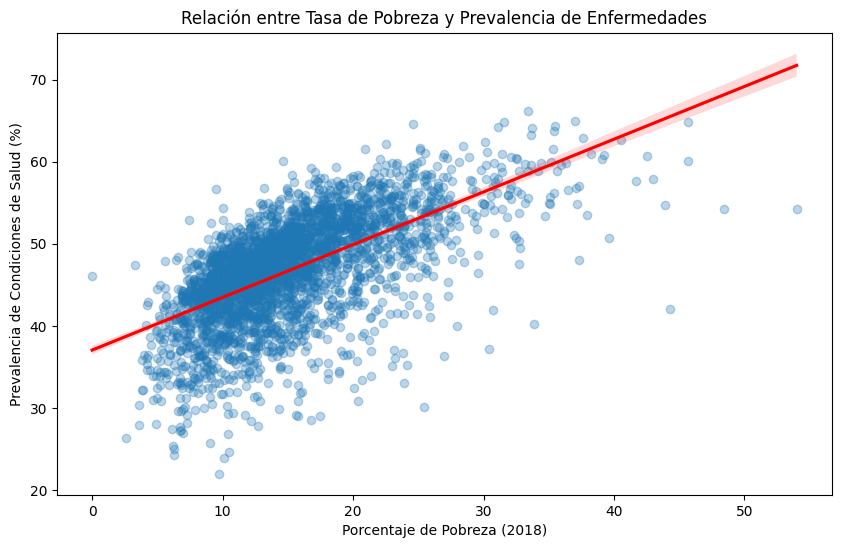

In [59]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='PCTPOVALL_2018', y='anycondition_prevalence', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relación entre Tasa de Pobreza y Prevalencia de Enfermedades')
plt.xlabel('Porcentaje de Pobreza (2018)')
plt.ylabel('Prevalencia de Condiciones de Salud (%)')
plt.show()

# Preparación, Limpieza y Split

Para que el modelo sea válido, antes de entrenar haré una limpieza final. Se decidió sacar la prevalencia de condiciones de salud específicas porque este es lo que se quiere predecir en general.

Obesity_prevalence y diabetes_prevalence son casi lineales con el valor buscado y el modelo no servirá para predecir salud a partir de recursos socioeconómicos.

Heart disease_prevalence: Es el porcentaje (%) de adultos en el condado a los que se les ha diagnosticado alguna enfermedad cardíaca (incluyendo ataques al corazón, angina o enfermedad coronaria).

COPD_prevalence: Es el porcentaje (%) de adultos que sufren de EPOC (Enfermedad Pulmonar Obstructiva Crónica). Es una enfermedad respiratoria estrechamente ligada al tabaquismo y a la contaminación ambiental.

CKD_

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos las que "hacen trampa" (prevalencias específicas y sus intervalos)
cols_prevalence_especificas = [col for col in df.columns if 'prevalence' in col and col != 'anycondition_prevalence']

# 2. Creamos X e y
X = df.drop(columns=['anycondition_prevalence'] + cols_prevalence_especificas)
X = X.select_dtypes(include=[np.number]).fillna(X.median()) # Limpiamos nulos con la mediana
y = df.loc[X.index, 'anycondition_prevalence']

# 3. Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalado (Vital para que Lasso compare variables justamente)
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

# Regresión Lineal vs Lasso (Base)

In [63]:
# Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_scal, y_train)
r2_lr = r2_score(y_test, lr.predict(X_test_scal))

# Lasso Base (alpha=1.0)
lasso_base = Lasso(alpha=1.0)
lasso_base.fit(X_train_scal, y_train)
r2_lasso_base = r2_score(y_test, lasso_base.predict(X_test_scal))

print(f"R2 Regresión Lineal: {r2_lr:.4f}")
print(f"R2 Lasso (Alpha 1.0): {r2_lasso_base:.4f}")

R2 Regresión Lineal: 0.8034
R2 Lasso (Alpha 1.0): 0.6885


# Evolución del R2 en Lasso (Alpha 0 a 20)

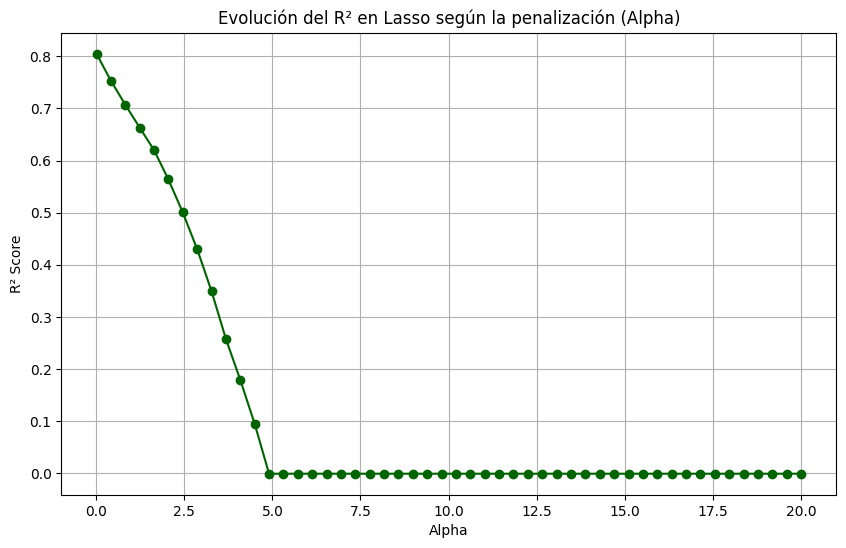

In [64]:
alphas = np.linspace(0.01, 20, 50)
r2_evolucion = []

for a in alphas:
    m_lasso = Lasso(alpha=a)
    m_lasso.fit(X_train_scal, y_train)
    r2_evolucion.append(r2_score(y_test, m_lasso.predict(X_test_scal)))

plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_evolucion, marker='o', color='darkgreen')
plt.title('Evolución del R² en Lasso según la penalización (Alpha)')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()

# Optimización (Interacciones Polinómicas)

In [65]:
from sklearn.preprocessing import PolynomialFeatures

# Creamos interacciones de segundo grado (solo entre las variables más importantes para no saturar)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scal)
X_test_poly = poly.transform(X_test_scal)

# Lasso Optimizado (usamos un Alpha pequeño como 0.1 para que elija las mejores interacciones)
lasso_opt = Lasso(alpha=0.1, max_iter=10000)
lasso_opt.fit(X_train_poly, y_train)

print(f"R2 Lasso Optimizado (Con Polinomios): {r2_score(y_test, lasso_opt.predict(X_test_poly)):.4f}")

R2 Lasso Optimizado (Con Polinomios): 0.8178
